# run always

In [300]:
fdir = r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231101_m2_GCaMPonly_Op&Ext/operant8' # where the imaging file is 
#fdir = r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231128_f1_GCaMPonly_Pav&Op/op' # where the imaging file is
savedir=fdir
fs=7.5 # acquisition frequency 
#pre_window_size = int(5*7.5) # frames before event
#window_size = int(7.5*15) # Total number of frames plotted around event
#frames_to_reward = int(10*7.5) # event to end frames

load_labels='F' # do you want to load sort labels from another day? if yes(T)- put that day as labeldir. no=='F'


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage as sk
import seaborn as sns
import cv2
import matplotlib as mpl
import math
import scipy
from scipy import stats
import sklearn
from sklearn import metrics
from matplotlib import colors

def normalize(data):
    data=(data-np.min(data))/(np.max(data)-np.min(data))
    return data

# individual days

In [302]:
#run this if only analyzing one file
import os
for file in os.listdir(fdir):
    if file.endswith(".csv"):
        fname=file
path_to_file=os.path.join(fdir,fname)
data = pd.read_csv(path_to_file,sep =',',header=None)
data=data.to_numpy()

dataTime=data[1:,0].astype('int')
data0=data[1:,1].astype('float') # clock
data1=data[1:,2].astype('float') # solenoid
data2=data[1:,3].astype('float') # active rotation  
data3=data[1:,4].astype('float') # tone
#data4=data[1:,5].astype('float') # inactive rotation

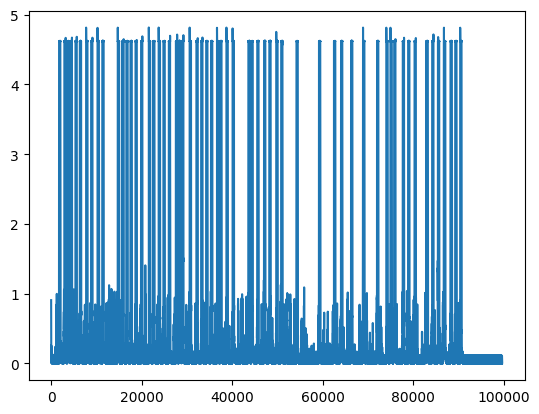

In [303]:
plt.plot((data3))

In [304]:
trial_on=10*(np.array(np.where(np.diff(data3)>1))+1) # find where contingency is met 
#trial_off=#np.array(np.where(np.diff(data3)<-2))+1 # find where contingency is met
trial_off=trial_on+3000
#print(trial_on, trial_off)
np.mean(np.diff(trial_on).T)

15028.474576271186

In [305]:
print (np.diff(trial_on)/1000)

[[11.77  7.32  6.61 10.61  9.61 14.07 10.97 14.24 10.52 34.24  9.99  8.82
   9.11 11.1  12.29 17.26  9.48 12.32 10.44 11.81 15.58  6.44  7.39 16.79
  14.89 10.44 11.02 10.73 13.36  7.01 13.85 13.61 34.68  6.87 12.8  14.99
  11.72 15.41 10.72 33.86 49.68 33.31 15.42 22.25 26.59 30.8  20.62  9.15
   8.07 18.98 11.84 14.21 26.45 12.5  12.73 13.49 14.41 10.31 11.13]]


In [306]:
np.save('trial_ITI2025op5m2.npy', np.diff(trial_on/1000))

deriv=np.expand_dims(np.hstack(([1000001], np.squeeze(np.diff(trial_on),axis=0))), axis=0)
trial_on=trial_on[deriv<11000] #change this number to what ITI is

In [272]:
pre_window=6000
post_window=4000

trial=np.zeros((trial_on.shape[1],4)).astype('int') # build array for PSTH= col 0 will be pre 
trial[:,1]=trial_on
trial[:,2]=trial_off

trial_length=stats.mode(trial[:,2]-trial[:,1])[0][0] # Find most common trial length 
trial[:,0]=trial[:,1]-pre_window # define first frame for PSTH
trial[:,3]=trial[:,2]+post_window # define last frame for PSTH

#trial is time in ms  of event

/var/folders/j9/cls849850j3b0tq8_9hhrwz855kg50/T/ipykernel_81247/771208210.py:8: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  trial_length=stats.mode(trial[:,2]-trial[:,1])[0][0] # Find most common trial length


In [273]:
np.diff(trial_on/1000)[np.diff(trial_on/1000)>10]

array([12.63, 15.68, 16.19, 23.45, 12.36, 15.13, 11.63, 13.79, 18.3 ,
       15.13, 10.58, 14.42, 15.58, 13.93, 13.01, 10.3 , 22.27, 14.85,
       14.85, 11.25, 17.62, 11.65, 17.6 , 12.18, 12.69, 16.19, 44.16,
       16.24, 12.38, 30.04, 23.62, 29.94, 15.45, 24.97, 15.75, 12.75,
       26.01, 14.16, 45.32, 18.41, 14.86, 15.9 , 24.27, 27.8 , 22.52])

In [274]:
np.mean(np.diff(trial_on/1000)[np.diff(trial_on/1000)>1]), np.std(np.diff(trial_on/1000)[np.diff(trial_on/1000)>1]), trial_on.shape[1]

(16.7222641509434, 7.878901762734954, 54)

In [275]:
# plot things

#Load imaging files
os.chdir(fdir)
F=np.load('F.npy')
iscell=np.load('iscell.npy')
Fneu=np.load('Fneu.npy')
redcells=np.load('redcellsre.npy')-1
from scipy import signal

fs=7.5 # in Hz (sampling frequency)
nyquist = fs * 0.5 
cutoff=0.2 # fraction of nyquist frequency
#start=time.time()
b, a = signal.butter(2, cutoff, btype='lowpass') #low pass filter


In [1]:
num_cells=0;
# count the number of cells listed as cells in suite2p
for cell in iscell[:,0]:
    if cell==1:
        num_cells=num_cells+1
#put all cells into array    
num_frames=F.shape[1];
cells_f=np.zeros([redcells.shape[0],num_frames]) # initialize array
cells_df=np.zeros([redcells.shape[0],num_frames]) # initialize array
#fill array

f_counter=0
df_counter=0
i=0
for cell in iscell[:,0]:
    if cell==1:
        if np.intersect1d(i,redcells).shape[0]>0 :
            Ff=signal.filtfilt(b, a, F[i,:]-Fneu[i,:]) # neuropil subtraction
            cells_f[f_counter]=Ff
            F0=np.mean(Ff)
            f_counter=f_counter+1
            if F0==0:
                F0=0.000001
                print (i)
            cells_df[df_counter]=(Ff-F0)/np.std(Ff)
                #print(cells_df[df_counter])
            df_counter=df_counter+1
        i=i+1    

cells_df=cells_df[cells_df[:,0]!=0]
cells_f=cells_f[cells_f[:,0]!=0]

print(cells_df.shape)
print('cells')

NameError: name 'iscell' is not defined

In [277]:
time=np.linspace(0,cells_df.shape[1]/7.5,cells_df.shape[1])

Text(0.5, 1.0, 'cell718')

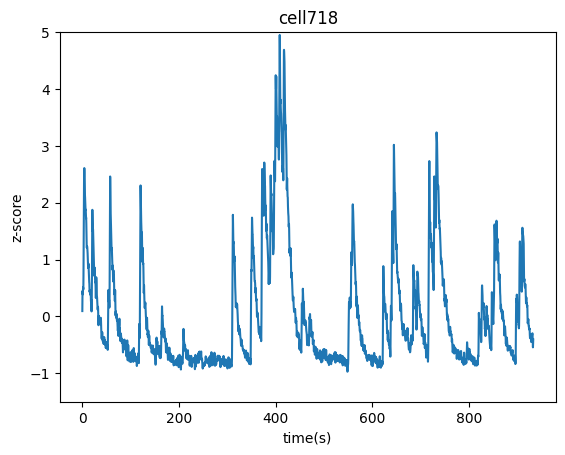

In [278]:
plt.plot(time,cells_df[0])
plt.ylim(-1.5,5)
plt.ylabel('z-score')
plt.xlabel('time(s)')
plt.title('cell718')
#os.chdir(r'F:\20231101_D1Tom_ForAnalyses\20240313_plots\tracked cells')
#plt.savefig('cell718_day1.svg')

In [279]:
frame=np.linspace(0,cells_df.shape[1]/fs*1000,cells_df.shape[1]).astype('float') # frame time in ms
print(np.max(frame))
print(np.max(dataTime))

933333.3333333334
996520


In [280]:
trial[0:5,:]

array([[16160, 22160, 25160, 29160],
       [28790, 34790, 37790, 41790],
       [44470, 50470, 53470, 57470],
       [60660, 66660, 69660, 73660],
       [84110, 90110, 93110, 97110]])

In [281]:
trial_frames=(trial/133).astype('int')
print(trial_frames)

[[ 121  166  189  219]
 [ 216  261  284  314]
 [ 334  379  402  432]
 [ 456  501  523  553]
 [ 632  677  700  730]
 [ 725  770  793  823]
 [ 786  831  854  884]
 [ 900  945  967  998]
 [ 963 1008 1031 1061]
 [1020 1065 1087 1117]
 [1107 1152 1175 1205]
 [1211 1256 1278 1309]
 [1348 1393 1416 1446]
 [1462 1507 1530 1560]
 [1542 1587 1609 1639]
 [1650 1695 1718 1748]
 [1767 1812 1835 1865]
 [1872 1917 1940 1970]
 [1970 2015 2037 2068]
 [2047 2092 2115 2145]
 [2215 2260 2282 2312]
 [2326 2371 2394 2424]
 [2438 2483 2506 2536]
 [2523 2568 2590 2620]
 [2595 2640 2663 2693]
 [2728 2773 2795 2826]
 [2791 2836 2859 2889]
 [2878 2924 2946 2976]
 [3011 3056 3078 3109]
 [3102 3147 3170 3200]
 [3198 3243 3265 3296]
 [3260 3305 3328 3358]
 [3382 3427 3450 3480]
 [3714 3759 3782 3812]
 [3836 3881 3904 3934]
 [3929 3974 3997 4027]
 [4155 4200 4223 4253]
 [4333 4378 4400 4430]
 [4558 4603 4626 4656]
 [4674 4719 4742 4772]
 [4862 4907 4929 4960]
 [4980 5025 5048 5078]
 [5054 5099 5121 5151]
 [5150 5195

In [282]:
# load 2p data for PSTH
trial1=trial
max_trial_frame_length=np.max(trial_frames[:,3]-trial_frames[:,0]).astype(int) 
min_trial_frame_length=np.min(trial_frames[:,3]-trial_frames[:,0]).astype(int) 
trial_PSTH=np.zeros([cells_df.shape[0],max_trial_frame_length, trial_frames.shape[0]])

trial_counter=0
for trial1 in trial_frames:
    trial_frame_length=trial1[3]-trial1[0]
    df_window=8
    cell_counter=0
    while cell_counter<cells_df.shape[0]:
        #normalize 1
        F_temp=cells_df[cell_counter,trial1[0]:trial1[3]]
        if (F_temp.shape[0])>0:
            f0=np.nanmean(F_temp[0:df_window])
            df=(F_temp-f0)/np.nanstd(F_temp[0:df_window])
            trial_PSTH[cell_counter,0:trial_frame_length, trial_counter]=df
        cell_counter=cell_counter+1
    trial_counter=trial_counter+1

trial_PSTH=trial_PSTH[:,0:min_trial_frame_length,:]

In [283]:
trial_PSTH.shape

(737, 97, 54)

In [284]:
# using stable because of historical reasons, doesnt mean anything 
trial_stable=np.nanmean(trial_PSTH[:,:,:],axis=2)

outcome_activity_mean=np.nanmean(trial_stable[:,0:97], axis=1) # axis 0= time, axis1=cells,

if load_labels=='F':
    print('sorting')
    sort_response_trial=np.argsort(outcome_activity_mean)
    np.save('sort_response_redtrial2025f1opforpav.npy', sort_response_trial)
else:
    sort_response_trial=np.load(os.path.join(labeldir, 'sort_response_redtrial2025f1opforpav.npy'))
    print('labels loaded')
trial_sort=trial_stable[sort_response_trial][::-1]

np.save('trial_redstable2025f1opforpav.npy', trial_stable)
np.save('trial_redPSTH2025f1opforpav.npy', trial_PSTH)
print (trial_PSTH.shape)
print (trial_PSTH)

sorting
(737, 97, 54)
[[[-9.89768264e-01  1.01539841e+00 -1.73599793e+00 ...  1.31737001e+00
    1.31436327e+00 -1.97659149e+00]
  [-1.25336336e+00  9.51946500e-01 -1.26472237e+00 ...  1.02834467e+00
    1.33676049e+00 -1.12037833e+00]
  [-1.00498822e+00  7.90329108e-01 -5.53125755e-01 ...  7.66101202e-01
    7.94802440e-01 -3.51203968e-01]
  ...
  [ 1.24051825e+01 -9.46861835e+00  4.93039749e+01 ... -8.43210173e+00
   -1.79129902e+01 -2.58704127e+00]
  [ 1.33627143e+01 -9.61241033e+00  5.65067394e+01 ... -8.71532400e+00
   -1.70953607e+01 -2.67581227e+00]
  [ 1.30793735e+01 -9.83341615e+00  6.28827291e+01 ... -8.93456456e+00
   -1.70862318e+01 -2.81276042e+00]]

 [[-8.82770067e-01 -1.90734801e+00  1.43542484e+00 ... -1.59315063e-01
    1.31437992e+00  1.15765811e+00]
  [ 5.78032416e-01 -1.09384136e+00  1.24350633e+00 ... -7.32604140e-01
    1.21427679e+00  1.30962060e+00]
  [ 1.41937998e+00 -3.44584751e-01  8.12251840e-01 ... -1.05934301e+00
    8.72774009e-01  9.91862189e-01]
  ...
 

In [285]:
os.chdir(fdir)
np.save('trial_redstable2025f1opforpav.npy', trial_stable)

In [105]:
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
# orange black
cdict = {'red':   ((0.0,  0.0, 0.0), # firs num= where on map proportion,second num= value, third num=alpha
                   (0.5,  1.0, 1.0),
                   (1.0,  246/255, 1.0)),

         'green': ((0.0,  0.0, 0.0),
                   (0.5, 1.0, 1.0),
                   (1.0, 147/255, 0)),

         'blue':  ((0.0,  0.0, 0.0),
                   (0.5,  1.0, 1.0),
                   (1.0,  32/255, 0))}

orangeBlack= LinearSegmentedColormap('orangeBlack', segmentdata=cdict, N=256)

# purple black
R=127
G=63
B=152
cdict2 = {'red':   ((0.0,  0.0, 0.0), # firs num= where on map proportion,second num= value, third num=alpha
                   (0.5,  1.0, 1.0),
                   (1.0,  R/255, 1.0)),

         'green': ((0.0,  0.0, 0.0),
                   (0.5, 1.0, 1.0),
                   (1.0, G/255, 0)),

         'blue':  ((0.0,  0.0, 0.0),
                   (0.5,  1.0, 1.0),
                   (1.0,  B/255, 0))}

purpleBlack= LinearSegmentedColormap('purpleBlack', segmentdata=cdict2, N=256)

# red black
R=237
G=28
B=36
cdict3 = {'red':   ((0.0,  0.0, 0.0), # firs num= where on map proportion,second num= value, third num=alpha
                   (0.5,  1.0, 1.0),
                   (1.0,  R/255, 1.0)),

         'green': ((0.0,  0.0, 0.0),
                   (0.5, 1.0, 1.0),
                   (1.0, G/255, 0)),

         'blue':  ((0.0,  0.0, 0.0),
                   (0.5,  1.0, 1.0),
                   (1.0,  B/255, 0))}

redBlack= LinearSegmentedColormap('redBlack', segmentdata=cdict3, N=256)

# brown black
R=169
G=124
B=80
cdict4 = {'red':   ((0.0,  0.0, 0.0), # firs num= where on map proportion,second num= value, third num=alpha
                   (0.5,  1.0, 1.0),
                   (1.0,  R/255, 1.0)),

         'green': ((0.0,  0.0, 0.0),
                   (0.5, 1.0, 1.0),
                   (1.0, G/255, 0)),

         'blue':  ((0.0,  0.0, 0.0),
                   (0.5,  1.0, 1.0),
                   (1.0,  B/255, 0))}

brownBlack= LinearSegmentedColormap('brownBlack', segmentdata=cdict4, N=256)



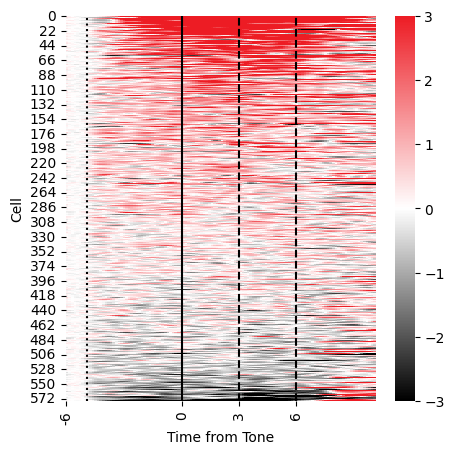

In [106]:
# make the heatplot
window_size=trial_stable.shape[1]-1
end1=trial_stable.shape[0]-1
divnorm=colors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)  

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5)) 
axs=ax
cax = sns.heatmap(trial_sort, # T for transpose
                    ax=axs,
                    cmap=redBlack,#,
                    norm=divnorm,
                    cbar=True)

axs.set_title("" )
axs.set_ylabel('Cell')
axs.set_xlabel('Time from Tone')
axs.grid(False)
axs.set_xticks([0,45,45+22,45+22+22])
axs.set_xticklabels((['-6','0','3','6',]))
axs.axvline(8, color='k', linestyle='dotted')
axs.axvline(45, color='k', linestyle='-')
axs.axvline(45+22, color='k', linestyle='--')
axs.axvline(45+22+22, color='k', linestyle='--') 
    

os.chdir(savedir)
#fig.savefig('PSTH_red2025m2op1.png', format='png', dpi=300)

In [717]:
time=np.linspace(-6, 7, trial_sort.shape[1])

In [12]:
#plt.plot(np.mean(trial_sort, axis=0), color='darkRed')
sns.lineplot(x=time, y=np.mean(trial_sort, axis=0), color= [237/256,28/256, 36/256])
plt.fill_between(time, np.mean(trial_sort, axis=0)-np.std(trial_sort, axis=0)/np.sqrt(trial_sort.shape[0]),  np.mean(trial_sort, axis=0) + np.std(trial_sort, axis=0)/np.sqrt(trial_sort.shape[0]), facecolor= [237/256,28/256, 36/256], alpha=0.5)    
plt.axvline(-5, color='k', linestyle='dotted')
plt.axvline(0, color='k', linestyle='-')
plt.axvline(3, color='k', linestyle='--')
plt.axvline(6, color='k', linestyle='--') 
plt.xlim(-6,7)
plt.ylim(-0.5,2)
#plt.savefig('meanSEM_2025m2op1.svg')

NameError: name 'time' is not defined

## combine multiple days

In [5]:
#load all the files from different animals

#os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231101_f1_GCaMPonly_Op&Ext/operant8')
os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses')
trial_stable=np.load('trial_redstable2025f1.npy')
trial_stable=trial_stable[:,0:97]
#redcells=np.unique(np.load('redcells.npy'))
print(trial_stable.shape)

#os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231101_f2_GCaMPonly_Op&Ext/operant8')
os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses')
#redcells=np.hstack((redcells, np.unique(np.load('redcells.npy'))+trial_stable.shape[0]))
trial_stable=np.vstack((trial_stable,np.load('trial_redstable2025f2.npy')[:,0:97]))
print(trial_stable.shape)

#os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231101_m2_GCaMPonly_Op&Ext/operant8')
os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses')
#redcells=np.hstack((redcells, np.unique(np.load('redcells.npy'))+trial_stable.shape[0]))
trial_stable=np.vstack((trial_stable,np.load('trial_redstable2025m2.npy')[:,0:97]))
print(trial_stable.shape)

#os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231101_m2_GCaMPonly_Op&Ext/operant8')
#redcells=np.hstack((redcells, np.unique(np.load('redcells.npy'))+trial_stable.shape[0]))
#trial_stable=np.vstack((trial_stable,np.load('trial_redstabletest2.npy')[:,0:127]))
#print(trial_stable.shape)

#os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231101_m4_GCaMPonly_Op&Ext/operant5')
#redcells=np.hstack((redcells, np.unique(np.load('redcells.npy'))+trial_stable.shape[0]))
#trial_stable=np.vstack((trial_stable,np.load('trial_redstabletest.npy')[:,0:127]))
#print(trial_stable.shape)

#os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses')
#np.save('trial_stableZ.npy', trial_stable)
#clusterlabels=np.load('clusterlabelsnew_op8.npy')

os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses')
np.save('trial_redstable2025op8.npy',trial_stable)
trial_stable=trial_stable[:,0:97]
#redcells=np.unique(np.load('redcells.npy'))

(576, 97)
(2090, 97)
(3552, 97)


In [540]:
os.chdir(r'/Users/raajgs/Documents/2p Analysis/20231101_D1Tom_ForAnalyses/20231101_f2_GCaMPonly_Op&Ext/operant1')
trial_stable=np.load('trial_redstableUSE1.npy')
#trial_stable=trial_stable[:,0:97]
#redcells=np.unique(np.load('redcells.npy'))
print(trial_stable.shape)

(1514, 97)


In [14]:
os.chdir(r'F:\20240108_D1tomgalvostim_analyses\M2opstimscale\M2op512')
trial_stable=np.load('trial_stable.npy')
trial_stable=trial_stable[:,0:127]
#redcells=np.unique(np.load('redcells.npy'))
print(trial_stable.shape)

os.chdir(r'F:\20240108_D1tomgalvostim_analyses\F2opstimscale\F2opscale')
#redcells=np.hstack((redcells, np.unique(np.load('redcells.npy'))+trial_stable.shape[0]))
trial_stable=np.vstack((trial_stable,np.load('trial_stable.npy')[:,0:127]))
print(trial_stable.shape)

os.chdir(r'F:\20240108_D1tomgalvostim_analyses\clustering')
np.save('trial_stable.npy', trial_stable)

FileNotFoundError: [Errno 2] No such file or directory: 'F:\\20240108_D1tomgalvostim_analyses\\M2opstimscale\\M2op512'

#load all the files from different animals
trial=0
os.chdir(r'F:\20231101_D1Tom_ForAnalyses\20231101_F2_GCaMPonly_Op&Ext\operant1')
trial_PSTH=np.load('trial_PSTH.npy')[:,0:127,:]
trial=trial_PSTH.shape[2]
print(trial)

os.chdir(r'F:\20231101_D1Tom_ForAnalyses\20231101_F2_GCaMPonly_Op&Ext\operant5')
trial_PSTH=np.concatenate((trial_PSTH,np.load('trial_PSTH.npy')[:,0:127,:]),axis=2)
trial=trial_PSTH.shape[2]
print(trial)

os.chdir(r'F:\20231101_D1Tom_ForAnalyses\20231101_F2_GCaMPonly_Op&Ext\operant8')
trial_PSTH=np.concatenate((trial_PSTH,np.load('trial_PSTH.npy')[:,0:127,:]),axis=2)
trial=trial_PSTH.shape[2]
print(trial)

os.chdir(r'F:\20231101_D1Tom_ForAnalyses\20231101_F2_GCaMPonly_Op&Ext\ext')
trial_PSTH=np.concatenate((trial_PSTH,np.load('trial_PSTH.npy')[:,0:127,:]),axis=2)
trial=trial_PSTH.shape[2]
print(trial)

os.chdir(r'F:\20231101_D1Tom_ForAnalyses')
clusterlabels=np.load('clusterlabels.npy')[7213:11246]

In [ ]:
trial_PSTH=trial_stable

In [ ]:
clusterlabels.shape

In [ ]:
c1_PSTH=trial_PSTH[clusterlabels==0]
c2_PSTH=trial_PSTH[clusterlabels==1]
c3_PSTH=trial_PSTH[clusterlabels==2]
c4_PSTH=trial_PSTH[clusterlabels==3]

In [ ]:
c1_PSTH.shape

In [ ]:
c1_trials=np.nanmean(c1_PSTH,axis=0).T
c2_trials=np.nanmean(c2_PSTH,axis=0).T
c3_trials=np.nanmean(c3_PSTH,axis=0).T
c4_trials=np.nanmean(c4_PSTH,axis=0).T

In [ ]:

sort_response_trial1=np.argsort(np.nanmean(c1_PSTH[:,75:98], axis=1))
c1_sort=c1_PSTH[sort_response_trial1][::-1]

sort_response_trial2=np.argsort(np.nanmean(c2_PSTH[:,36:75], axis=1))
c2_sort=c2_PSTH[sort_response_trial2][::-1]

sort_response_trial3=np.argsort(np.nanmean(c3_PSTH[:,98:120], axis=1))
c3_sort=c3_PSTH[sort_response_trial3][::-1]


sort_response_trial4=np.argsort(np.nanmean(c4_PSTH[:,36:120], axis=1))
c4_sort=c4_PSTH[sort_response_trial4][::-1]


In [ ]:
window_size=trial_PSTH.shape[1]-1
end1=trial_PSTH.shape[0]-1
divnorm=colors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)  

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,10)) 
axs=ax
cax = sns.heatmap((c1_sort), # T for transpose
                    ax=axs,
                    cmap=redBlack,#,
                    norm=divnorm,
                    cbar=True)

axs.set_title("Cluster2" )
axs.set_ylabel('Trial')
axs.set_xlabel('Time from Tone')
axs.grid(False)
axs.set_xticks([0,75,75+22, 75+23+22])
axs.set_xticklabels((['-10','0','3','6',]))
axs.axvline(36, color='k', linestyle='dotted')
axs.axvline(75, color='k', linestyle='-')
axs.axvline(75+23, color='k', linestyle='--')
axs.axvline(75+23+22, color='k', linestyle='--')

os.chdir(r'F:\20231101_D1Tom_ForAnalyses\20240313_plots\op5')
fig.savefig('cluster2.png', format='png', dpi=300)

In [ ]:
time=np.linspace(-10,6,127)

In [ ]:
#plt.plot(np.mean(trial_sort, axis=0), color='darkRed')
fig,ax=plt.subplots(ncols=4, figsize=(15,4))
plot_sort=c1_sort
axs=ax[0]
axs.plot(time, np.mean(plot_sort, axis=0), color= [237/256,28/256, 36/256])
axs.fill_between(time, np.mean(plot_sort, axis=0)-np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]),  np.mean(plot_sort, axis=0) + np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]), facecolor= [237/256,28/256, 36/256], alpha=0.5)    
axs.axvline(-5, color='k', linestyle='dotted')
axs.axvline(0, color='k', linestyle='-')
axs.axvline(3, color='k', linestyle='--')
axs.axvline(6, color='k', linestyle='--') 
axs.set_xlim(-10,6)
axs.set_ylim(-0.1,1.3)
axs.set_xlabel('time from tone(s)')
axs.set_ylabel('mean z')
axs.set_title('cluster 1')

plot_sort=c2_sort
axs=ax[1]
axs.plot(time, np.mean(plot_sort, axis=0), color= [237/256,28/256, 36/256])
axs.fill_between(time, np.mean(plot_sort, axis=0)-np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]),  np.mean(plot_sort, axis=0) + np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]), facecolor= [237/256,28/256, 36/256], alpha=0.5)    
axs.axvline(-5, color='k', linestyle='dotted')
axs.axvline(0, color='k', linestyle='-')
axs.axvline(3, color='k', linestyle='--')
axs.axvline(6, color='k', linestyle='--') 
axs.set_xlim(-10,6)
axs.set_ylim(-0.1,1.3)
axs.set_title('cluster 2')

plot_sort=c3_sort
axs=ax[2]
axs.plot(time, np.mean(plot_sort, axis=0), color= [237/256,28/256, 36/256])
axs.fill_between(time, np.mean(plot_sort, axis=0)-np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]),  np.mean(plot_sort, axis=0) + np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]), facecolor= [237/256,28/256, 36/256], alpha=0.5)    
axs.axvline(-5, color='k', linestyle='dotted')
axs.axvline(0, color='k', linestyle='-')
axs.axvline(3, color='k', linestyle='--')
axs.axvline(6, color='k', linestyle='--') 
axs.set_xlim(-10,6)
axs.set_ylim(-0.1,1.3)
axs.set_title('cluster 3')

plot_sort=c4_sort
axs=ax[3]
axs.plot(time, np.mean(plot_sort, axis=0), color= [237/256,28/256, 36/256])
axs.fill_between(time, np.mean(plot_sort, axis=0)-np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]),  np.mean(plot_sort, axis=0) + np.std(plot_sort, axis=0)/np.sqrt(plot_sort.shape[0]), facecolor= [237/256,28/256, 36/256], alpha=0.5)    
axs.axvline(-5, color='k', linestyle='dotted')
axs.axvline(0, color='k', linestyle='-')
axs.axvline(3, color='k', linestyle='--')
axs.axvline(6, color='k', linestyle='--') 
axs.set_xlim(-10,6)
axs.set_ylim(-0.1,1.3)
axs.set_title('cluster 4')

plt.savefig('mean_z.svg')

In [ ]:
print(np.nanmax((np.mean(c1_sort[:,75:98],axis=0))), np.nanstd((np.mean(c1_sort[:,75:98],axis=0)))/np.sqrt(np.sqrt(c1_sort.shape[0])))
print(np.nanmax((np.mean(c2_sort[:,36:75],axis=0))), np.nanstd((np.mean(c2_sort[:,36:75],axis=0)))/np.sqrt(np.sqrt(c2_sort.shape[0])))
print(np.nanmax((np.mean(c3_sort[:,:],axis=0))), np.nanstd((np.mean(c3_sort[:,98:120],axis=0)))/np.sqrt(np.sqrt(c3_sort.shape[0])))
print(np.nanmax((np.mean(c4_sort[:,36:120],axis=0))), np.nanstd((np.mean(c4_sort[:,36:120],axis=0)))/np.sqrt(np.sqrt(c4_sort.shape[0])))

In [ ]:
c4_sort.shape